# Visualizzare gli environment con diversi observation space

Questo notebook mostra lo stesso ciclo RL per `SurrogateEnv` e `TraceWinEnv`:

```text
obs_t -> action -> obs_{t+1}, reward, info["sim_result"]
```

La cosa principale da vedere qui e come cambia l'osservazione quando scegli:

```text
obs_mode="full"              -> tutti gli stage: 12 x 9 = 108 valori
obs_mode="final"             -> solo ultimo stage: 9 valori
obs_mode="final_with_beam0"  -> stage iniziale + stage finale: 18 valori
```

Per ogni `obs_mode` applichiamo la stessa action multi-parametro e guardiamo direttamente l'effetto sul **final state**: tabella prima/dopo/delta e immagini sintetiche del fascio finale.

Le immagini sono sintetiche: vengono ricostruite dai dati dell'observation (`x0`, `y0`, `SizeX`, `SizeY`, `x'0`, `y'0`, `ex`, `ey`). Non sono file `.dst` veri.

Nota: le immagini sintetiche non possono ricostruire tutta la forma della distribuzione vera. In particolare, l'observation attuale non contiene `std(x')`, `std(y')` e le covarianze `x-x'`, `y-y'`.

Per TraceWin il notebook mostra tre livelli: sintetica povera da observable, sintetica arricchita da tutti i momenti di `partran1.out`, e distribuzione vera `.dst`.


In [ ]:
from pathlib import Path
import sys
import time
import shutil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except Exception:
    display = print

try:
    HERE = Path(__vsc_ipynb_file__).parent.resolve()
except NameError:
    HERE = Path().resolve()

# Il notebook vive in beam_optimization/env. Serve importare il package dalla root del repo.
sys.path.insert(0, str(HERE.parents[1]))

from beam_optimization.env.surrogate_env import SurrogateEnv, ModularMLP, SurrogateTrainingDataset
from beam_optimization.env.tracewin_env import TraceWinEnv
from beam_optimization.env.tracewin_env.tracewin.pyTraceWin_wrapper.files import Dst
from beam_optimization.config.paths import DEFAULT_DATASET, DEFAULT_SURROGATE_DIR, DEFAULT_TRACEWIN_INI
from beam_optimization.config.adige import BEAM_STATE_VARS, PARAMETERS, PARAM_KEYS

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 180)

print(f"Dataset surrogate: {DEFAULT_DATASET}")
print(f"Modelli surrogate: {DEFAULT_SURROGATE_DIR}")
print(f"TraceWin project:   {DEFAULT_TRACEWIN_INI}")


## 1. Caricamento Surrogate

Il surrogate ha bisogno di due cose:

- i pesi del modello neurale `surrogate_*.pt`;
- il dataset `dataset_train.pt`, usato anche per campionare il fascio iniziale `beam0` a ogni reset.


In [ ]:
model_files = sorted(Path(DEFAULT_SURROGATE_DIR).glob("surrogate_*.pt"))
if not model_files:
    raise FileNotFoundError(f"Nessun surrogate_*.pt trovato in {DEFAULT_SURROGATE_DIR}")

surrogates = [ModularMLP.load(str(p)) for p in model_files]
for model in surrogates:
    model.eval()

dataset = SurrogateTrainingDataset.load(str(DEFAULT_DATASET))

print(f"Caricati {len(surrogates)} modelli surrogate")
print(f"Dataset: {len(dataset):,} campioni")


## 2. Helper Comuni

Queste funzioni sono usate sia da `SurrogateEnv` sia da `TraceWinEnv`.

La dashboard fa sempre la stessa cosa:

1. crea l'ambiente con un certo `obs_mode`;
2. esegue `reset()` per ottenere `obs_t`;
3. applica una action multi-parametro da 16 delta;
4. esegue `step(action)` per ottenere `obs_{t+1}`;
5. mostra l'effetto della action sul final state.


In [ ]:
OBS_MODES = ("full", "final", "final_with_beam0")

VAR_UNITS = {
    "npart_ratio": "",
    "x0": "mm",
    "y0": "mm",
    "SizeX": "mm",
    "SizeY": "mm",
    "ex": "pi mm mrad",
    "ey": "pi mm mrad",
    "x'0": "mrad",
    "y'0": "mrad",
}

PARAM_LABELS = {p.key: p.name for p in PARAMETERS}
PARAM_SENS = {p.key: p.sensitivity for p in PARAMETERS}

# Preset didattico: action shape (16,), con 8 parametri attivi.
# I delta sono frazioni dei bound dell'action_space, quindi restano validi per tutti gli obs_mode.
MULTI_PARAM_ACTION_FRACTIONS = {
    "ele[2][5]": 0.35,     # AD.SO.01
    "ele[4][5]": -0.25,    # AD.SO.02
    "ele[10][1]": 0.60,    # AD.ST.04.X
    "ele[10][2]": -0.45,   # AD.ST.04.Y
    "ele[12][2]": 0.20,    # AD.1EQ.01
    "ele[16][2]": -0.18,   # AD.1EQ.02
    "ele[38][1]": -0.50,   # AD.ST.05.X
    "ele[38][2]": 0.40,    # AD.ST.05.Y
}


def make_multi_param_action(env, scale=1.0):
    action = np.zeros(env.action_space.shape, dtype=np.float32)
    for key, frac in MULTI_PARAM_ACTION_FRACTIONS.items():
        idx = list(PARAM_KEYS).index(key)
        action[idx] = float(scale) * frac * env.action_space.high[idx]
    return np.clip(action, env.action_space.low, env.action_space.high).astype(np.float32)


def action_table(params_before, action, params_after):
    rows = []
    for i, key in enumerate(PARAM_KEYS):
        delta = float(action[i])
        sensitivity = float(PARAM_SENS[key])
        rows.append({
            "active": abs(delta) > 1e-14,
            "parameter": PARAM_LABELS.get(key, key),
            "tracewin_key": key,
            "before": float(params_before[key]),
            "delta": delta,
            "after": float(params_after[key]),
            "sensitivity": sensitivity,
            "delta/sensitivity": delta / sensitivity if sensitivity else np.nan,
        })
    return pd.DataFrame(rows)


def beam_states_table(beam_states, digits=5):
    df = pd.DataFrame(np.asarray(beam_states), columns=BEAM_STATE_VARS)
    df.insert(0, "stage", np.arange(len(df)))
    return df.round(digits)


def final_metrics(beam_states):
    final = np.asarray(beam_states)[-1]
    return {var: float(final[i]) for i, var in enumerate(BEAM_STATE_VARS)}


def obs_to_table(obs, obs_mode):
    obs = np.asarray(obs, dtype=np.float32)
    if obs_mode == "full":
        return beam_states_table(obs.reshape(-1, len(BEAM_STATE_VARS)))
    if obs_mode == "final":
        df = pd.DataFrame([obs], columns=BEAM_STATE_VARS)
        df.insert(0, "stage", "final")
        return df.round(5)
    if obs_mode == "final_with_beam0":
        arr = obs.reshape(2, len(BEAM_STATE_VARS))
        df = pd.DataFrame(arr, columns=BEAM_STATE_VARS)
        df.insert(0, "stage", ["beam0", "final"])
        return df.round(5)
    raise ValueError(f"obs_mode non riconosciuto: {obs_mode}")


def final_state_effect_table(before_result, after_result):
    before = np.asarray(before_result.beam_states, dtype=np.float32)[-1]
    after = np.asarray(after_result.beam_states, dtype=np.float32)[-1]
    rows = []
    for i, var in enumerate(BEAM_STATE_VARS):
        rows.append({
            "variable": var,
            "unit": VAR_UNITS.get(var, ""),
            "final_before": float(before[i]),
            "final_after": float(after[i]),
            "delta": float(after[i] - before[i]),
        })
    return pd.DataFrame(rows).round(6)


def synthetic_particles_from_final(final_row, n_particles=20000, seed=123):
    rng = np.random.default_rng(seed)
    row = {var: float(final_row[var]) for var in BEAM_STATE_VARS}

    sigma_x = max(abs(row["SizeX"]), 1e-6)
    sigma_y = max(abs(row["SizeY"]), 1e-6)
    sigma_xp = max(abs(row["ex"]) / sigma_x, 1e-6)
    sigma_yp = max(abs(row["ey"]) / sigma_y, 1e-6)

    return {
        "x": rng.normal(row["x0"], sigma_x, n_particles),
        "xp": rng.normal(row["x'0"], sigma_xp, n_particles),
        "y": rng.normal(row["y0"], sigma_y, n_particles),
        "yp": rng.normal(row["y'0"], sigma_yp, n_particles),
    }


def plot_final_state_delta(before_result, after_result, title):
    table = final_state_effect_table(before_result, after_result)
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(title, fontsize=13)

    axes[0].bar(table["variable"], table["final_before"], alpha=0.55, label="prima")
    axes[0].bar(table["variable"], table["final_after"], alpha=0.55, label="dopo")
    axes[0].set_title("Final state: valori prima/dopo")
    axes[0].tick_params(axis="x", rotation=45)
    axes[0].grid(axis="y", alpha=0.25)
    axes[0].legend()

    colors = ["tab:green" if value >= 0 else "tab:red" for value in table["delta"]]
    axes[1].bar(table["variable"], table["delta"], color=colors, alpha=0.8)
    axes[1].axhline(0, color="black", lw=0.8)
    axes[1].set_title("Delta final state = dopo - prima")
    axes[1].tick_params(axis="x", rotation=45)
    axes[1].grid(axis="y", alpha=0.25)

    plt.tight_layout()
    plt.show()


def plot_final_state_images(before_result, after_result, title, n_particles=20000, bins=120):
    before_row = pd.Series(np.asarray(before_result.beam_states, dtype=np.float32)[-1], index=BEAM_STATE_VARS)
    after_row = pd.Series(np.asarray(after_result.beam_states, dtype=np.float32)[-1], index=BEAM_STATE_VARS)

    before_cloud = synthetic_particles_from_final(before_row, n_particles=n_particles, seed=701)
    after_cloud = synthetic_particles_from_final(after_row, n_particles=n_particles, seed=702)

    panels = [
        ("x", "y", "x [mm]", "y [mm]", "x-y"),
        ("x", "xp", "x [mm]", "x' [mrad]", "x-x'"),
        ("y", "yp", "y [mm]", "y' [mrad]", "y-y'"),
    ]

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    fig.suptitle(title, fontsize=13)

    for col, (a, b, xlabel, ylabel, subtitle) in enumerate(panels):
        all_a = np.concatenate([before_cloud[a], after_cloud[a]])
        all_b = np.concatenate([before_cloud[b], after_cloud[b]])
        xr = (np.nanpercentile(all_a, 0.5), np.nanpercentile(all_a, 99.5))
        yr = (np.nanpercentile(all_b, 0.5), np.nanpercentile(all_b, 99.5))

        for row, label, cloud in [
            (0, "prima action", before_cloud),
            (1, "dopo action", after_cloud),
        ]:
            ax = axes[row, col]
            h, xedge, yedge = np.histogram2d(cloud[a], cloud[b], bins=bins, range=[xr, yr])
            h_log = np.log1p(h)
            h_log[h_log == 0] = np.nan
            im = ax.pcolormesh(xedge, yedge, h_log.T, cmap="Blues", shading="auto")
            ax.axhline(0, color="black", lw=0.8, linestyle="--")
            ax.axvline(0, color="black", lw=0.8, linestyle="--")
            ax.plot(np.mean(cloud[a]), np.mean(cloud[b]), marker="+", color="red", markersize=12, mew=2)
            ax.set_title(f"{label} - {subtitle}", fontsize=10)
            ax.set_xlabel(xlabel, fontsize=9)
            ax.set_ylabel(ylabel, fontsize=9)
            ax.tick_params(labelsize=8)
            cb = fig.colorbar(im, ax=ax, pad=0.02, fraction=0.046)
            cb.set_label("log(counts+1)", fontsize=7)
            cb.ax.tick_params(labelsize=6)

    plt.tight_layout()
    plt.show()



def tracewin_final_dst_path(calc_dir):
    """Return part_dtl1.dst if present, otherwise the highest numbered *.dst."""
    calc_dir = Path(calc_dir)
    preferred = calc_dir / "part_dtl1.dst"
    if preferred.exists():
        return preferred

    numbered = []
    for path in calc_dir.glob("*.dst"):
        try:
            numbered.append((int(path.stem), path))
        except ValueError:
            continue
    if numbered:
        return max(numbered, key=lambda item: item[0])[1]

    fallback = sorted(calc_dir.glob("*.dst"))
    return fallback[-1] if fallback else None


def copy_tracewin_final_dst(calc_dir, label="before"):
    """Copy the best available final .dst before the next step cleans calc/."""
    src = tracewin_final_dst_path(calc_dir)
    if src is None:
        print(f"True TraceWin distribution not found in: {calc_dir}")
        return None

    dst_dir = Path("/tmp/tracewin_notebook_dst")
    dst_dir.mkdir(parents=True, exist_ok=True)
    dst = dst_dir / f"{src.stem}_{label}{src.suffix}"
    shutil.copy2(src, dst)
    return dst




def copy_tracewin_output_file(calc_dir, filename, label):
    """Copia un file di calc/ prima che lo step successivo pulisca la cartella."""
    src = Path(calc_dir) / filename
    if not src.exists():
        return None

    dst_dir = Path("/tmp/tracewin_notebook_dst")
    dst_dir.mkdir(parents=True, exist_ok=True)
    dst = dst_dir / f"{Path(filename).stem}_{label}{Path(filename).suffix}"
    shutil.copy2(src, dst)
    return dst


def aperture_from_partran(partran_path):
    """Legge l'apertura finale da partran1.out, come in visualize_distributions."""
    if partran_path is None or not Path(partran_path).exists():
        return None
    try:
        df = pd.read_csv(partran_path, sep=r"\s+", header=0, skiprows=9)
    except Exception:
        return None
    if df.empty or "Aper" not in df.columns:
        return None
    return float(df["Aper"].iloc[-1])

def tracewin_dst_cloud(dst_path, max_particles=40000, seed=123):
    """Legge un .dst TraceWin e restituisce x/y/xp/yp in mm/mrad."""
    dst = Dst(str(dst_path))
    n = int(dst.Np)
    idx = np.arange(n)
    if n > max_particles:
        rng = np.random.default_rng(seed)
        idx = rng.choice(idx, size=max_particles, replace=False)

    return {
        "n_total": n,
        "x": np.asarray(dst["x"])[idx] * 1e3,
        "xp": np.asarray(dst["xp"])[idx] * 1e3,
        "y": np.asarray(dst["y"])[idx] * 1e3,
        "yp": np.asarray(dst["yp"])[idx] * 1e3,
    }



def dst_moment_summary(dst_path, label):
    """Riassume i momenti RMS veri della distribuzione .dst finale."""
    cloud = tracewin_dst_cloud(dst_path, max_particles=10**12)
    rows = []
    for name in ["x", "y", "xp", "yp"]:
        values = cloud[name]
        rows.append({
            "distribution": label,
            "quantity": name,
            "mean": float(np.mean(values)),
            "std": float(np.std(values)),
            "p0.5": float(np.percentile(values, 0.5)),
            "p99.5": float(np.percentile(values, 99.5)),
        })

    x = cloud["x"]
    xp = cloud["xp"]
    y = cloud["y"]
    yp = cloud["yp"]
    rows.extend([
        {"distribution": label, "quantity": "cov(x,x')", "mean": float(np.cov(x, xp, bias=True)[0, 1]), "std": np.nan, "p0.5": np.nan, "p99.5": np.nan},
        {"distribution": label, "quantity": "cov(y,y')", "mean": float(np.cov(y, yp, bias=True)[0, 1]), "std": np.nan, "p0.5": np.nan, "p99.5": np.nan},
        {"distribution": label, "quantity": "corr(x,x')", "mean": float(np.corrcoef(x, xp)[0, 1]), "std": np.nan, "p0.5": np.nan, "p99.5": np.nan},
        {"distribution": label, "quantity": "corr(y,y')", "mean": float(np.corrcoef(y, yp)[0, 1]), "std": np.nan, "p0.5": np.nan, "p99.5": np.nan},
    ])
    return pd.DataFrame(rows)


def tracewin_observable_vs_dst_table(result, dst_path, label):
    """Confronta final state osservabile con momenti veri del .dst."""
    final = pd.Series(np.asarray(result.beam_states, dtype=np.float32)[-1], index=BEAM_STATE_VARS)
    cloud = tracewin_dst_cloud(dst_path, max_particles=10**12)
    return pd.DataFrame([
        {"source": label, "quantity": "x0 / mean(x)", "observable": final["x0"], "dst_moment": float(np.mean(cloud["x"]))},
        {"source": label, "quantity": "y0 / mean(y)", "observable": final["y0"], "dst_moment": float(np.mean(cloud["y"]))},
        {"source": label, "quantity": "x'0 / mean(x')", "observable": final["x'0"], "dst_moment": float(np.mean(cloud["xp"]))},
        {"source": label, "quantity": "y'0 / mean(y')", "observable": final["y'0"], "dst_moment": float(np.mean(cloud["yp"]))},
        {"source": label, "quantity": "SizeX / std(x)", "observable": final["SizeX"], "dst_moment": float(np.std(cloud["x"]))},
        {"source": label, "quantity": "SizeY / std(y)", "observable": final["SizeY"], "dst_moment": float(np.std(cloud["y"]))},
        {"source": label, "quantity": "std(x')", "observable": np.nan, "dst_moment": float(np.std(cloud["xp"]))},
        {"source": label, "quantity": "std(y')", "observable": np.nan, "dst_moment": float(np.std(cloud["yp"]))},
        {"source": label, "quantity": "cov(x,x')", "observable": np.nan, "dst_moment": float(np.cov(cloud["x"], cloud["xp"], bias=True)[0, 1])},
        {"source": label, "quantity": "cov(y,y')", "observable": np.nan, "dst_moment": float(np.cov(cloud["y"], cloud["yp"], bias=True)[0, 1])},
    ]).round(6)

def _limits_with_padding(values, low=0.5, high=99.5, pad_frac=0.15):
    lo, hi = np.nanpercentile(values, [low, high])
    if not np.isfinite(lo) or not np.isfinite(hi) or lo == hi:
        center = float(np.nanmean(values)) if len(values) else 0.0
        span = 1.0
        lo, hi = center - span, center + span
    pad = pad_frac * (hi - lo)
    return lo - pad, hi + pad


def phase_space_plots_like_visualize_distribution(
    dst_path,
    title,
    aper_mm=None,
    bins=200,
    zoom_percentiles=(0.5, 99.5),
):
    """Vista semplice della distribuzione vera: stessa logica delle sintetiche."""
    dst = Dst(str(dst_path))
    x = dst["x"] * 1e3
    xp = dst["xp"] * 1e3
    y = dst["y"] * 1e3
    yp = dst["yp"] * 1e3

    panels = [
        (x, y, "x [mm]", "y [mm]", "x-y"),
        (x, xp, "x [mm]", "x' [mrad]", "x-x'"),
        (y, yp, "y [mm]", "y' [mrad]", "y-y'"),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))
    fig.suptitle(title, fontsize=12)

    p_low, p_high = zoom_percentiles
    for ax, (cx, cy, lx, ly, subtitle) in zip(axes, panels):
        xlim = _limits_with_padding(cx, p_low, p_high)
        ylim = _limits_with_padding(cy, p_low, p_high)

        h, xedge, yedge = np.histogram2d(cx, cy, bins=bins, range=[xlim, ylim])
        h_log = np.log1p(h)
        h_log[h_log == 0] = np.nan

        im = ax.pcolormesh(xedge, yedge, h_log.T, cmap="Blues", shading="auto")
        ax.axhline(0, color="black", lw=0.8, linestyle="--")
        ax.axvline(0, color="black", lw=0.8, linestyle="--")

        mx = np.mean(cx)
        my = np.mean(cy)
        ax.plot(mx, my, marker="+", color="red", markersize=12, mew=2)

        ax.set_xlim(*xlim)
        ax.set_ylim(*ylim)
        ax.set_xlabel(lx, fontsize=9)
        ax.set_ylabel(ly, fontsize=9)
        ax.set_title(subtitle, fontsize=10)
        ax.tick_params(labelsize=8)

        cb = fig.colorbar(im, ax=ax, pad=0.02, fraction=0.046)
        cb.set_label("log(counts+1)", fontsize=7)
        cb.ax.tick_params(labelsize=6)

    plt.tight_layout()
    plt.show()


def partran_final_row(partran_path):
    """Ultima riga di partran1.out, cioe il final state TraceWin completo."""
    if partran_path is None or not Path(partran_path).exists():
        return None
    df = pd.read_csv(partran_path, sep=r"\s+", header=0, skiprows=9)
    if df.empty:
        return None
    return df.iloc[-1]


def _nearest_positive_semidefinite(cov, eps=1e-9):
    """Rende robusta una matrice di covarianza quasi-PSD."""
    cov = np.asarray(cov, dtype=float)
    cov = 0.5 * (cov + cov.T)
    eigvals, eigvecs = np.linalg.eigh(cov)
    eigvals = np.maximum(eigvals, eps)
    return (eigvecs * eigvals) @ eigvecs.T


def partran_full_covariance(row):
    """Covarianza 4D [x, y, x', y'] usando tutte le info utili di partran1.out.

    TraceWin scrive ex/ey come emittanze normalizzate. Per ricostruire la
    varianza angolare geometrica serve dividere per beta*gamma, dove
    beta*gamma = sqrt(gamma^2 - 1) e gamma = 1 + (gama-1).
    """
    gamma = 1.0 + float(row["gama-1"])
    beta_gamma = max(np.sqrt(max(gamma * gamma - 1.0, 0.0)), 1e-12)

    sx = max(float(row["SizeX"]), 1e-12)
    sy = max(float(row["SizeY"]), 1e-12)
    cov_x_xp = float(row["sxx'"])
    cov_y_yp = float(row["syy'"])

    eps_x_geo = abs(float(row["ex"])) / beta_gamma
    eps_y_geo = abs(float(row["ey"])) / beta_gamma

    # eps^2 = var(pos) * var(angle) - cov(pos, angle)^2
    sxp = np.sqrt(max((eps_x_geo**2 + cov_x_xp**2) / (sx**2), 1e-12))
    syp = np.sqrt(max((eps_y_geo**2 + cov_y_yp**2) / (sy**2), 1e-12))

    cov = np.array([
        [sx * sx,             float(row.get("Sxy", 0.0)),   cov_x_xp,              float(row.get("Sxy'", 0.0))],
        [float(row.get("Sxy", 0.0)), sy * sy,                float(row.get("Sx'y", 0.0)), cov_y_yp],
        [cov_x_xp,            float(row.get("Sx'y", 0.0)), sxp * sxp,              float(row.get("Sx'y'", 0.0))],
        [float(row.get("Sxy'", 0.0)), cov_y_yp,              float(row.get("Sx'y'", 0.0)), syp * syp],
    ], dtype=float)
    return _nearest_positive_semidefinite(cov)


def partran_synthetic_cloud(partran_path, n_particles=40000, seed=123):
    """Distribuzione sintetica 4D generata da tutti i momenti di partran1.out."""
    row = partran_final_row(partran_path)
    if row is None:
        return None

    mean = np.array([
        float(row["x0"]),
        float(row["y0"]),
        float(row["x'0"]),
        float(row["y'0"]),
    ], dtype=float)
    cov = partran_full_covariance(row)
    rng = np.random.default_rng(seed)
    sample = rng.multivariate_normal(mean, cov, size=n_particles)
    return {
        "x": sample[:, 0],
        "y": sample[:, 1],
        "xp": sample[:, 2],
        "yp": sample[:, 3],
        "row": row,
        "cov": cov,
    }


def plot_partran_synthetic_distribution(before_partran_path, after_partran_path, title, n_particles=40000, bins=120):
    """Gaussiana 4D da partran1.out, stesso layout di sintetica e vera TraceWin."""
    before_cloud = partran_synthetic_cloud(before_partran_path, n_particles=n_particles, seed=801)
    after_cloud = partran_synthetic_cloud(after_partran_path, n_particles=n_particles, seed=802)
    if before_cloud is None or after_cloud is None:
        print("Sintetica da partran1.out non disponibile: manca partran prima o dopo action.")
        return

    panels = [
        ("x", "y", "x [mm]", "y [mm]", "x-y"),
        ("x", "xp", "x [mm]", "x' [mrad]", "x-x'"),
        ("y", "yp", "y [mm]", "y' [mrad]", "y-y'"),
    ]

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    fig.suptitle(title, fontsize=13)

    for col, (a, b, xlabel, ylabel, subtitle) in enumerate(panels):
        all_a = np.concatenate([before_cloud[a], after_cloud[a]])
        all_b = np.concatenate([before_cloud[b], after_cloud[b]])
        xr = (np.nanpercentile(all_a, 0.5), np.nanpercentile(all_a, 99.5))
        yr = (np.nanpercentile(all_b, 0.5), np.nanpercentile(all_b, 99.5))

        for row_idx, label, cloud in [
            (0, "prima action", before_cloud),
            (1, "dopo action", after_cloud),
        ]:
            ax = axes[row_idx, col]
            h, xedge, yedge = np.histogram2d(cloud[a], cloud[b], bins=bins, range=[xr, yr])
            h_log = np.log1p(h)
            h_log[h_log == 0] = np.nan
            im = ax.pcolormesh(xedge, yedge, h_log.T, cmap="Blues", shading="auto")
            ax.axhline(0, color="black", lw=0.8, linestyle="--")
            ax.axvline(0, color="black", lw=0.8, linestyle="--")
            ax.plot(np.mean(cloud[a]), np.mean(cloud[b]), marker="+", color="red", markersize=12, mew=2)
            ax.set_title(f"{label} - {subtitle}", fontsize=10)
            ax.set_xlabel(xlabel, fontsize=9)
            ax.set_ylabel(ylabel, fontsize=9)
            ax.tick_params(labelsize=8)
            cb = fig.colorbar(im, ax=ax, pad=0.02, fraction=0.046)
            cb.set_label("log(counts+1)", fontsize=7)
            cb.ax.tick_params(labelsize=6)

    plt.tight_layout()
    plt.show()


def partran_vs_dst_moment_table(partran_path, dst_path, label):
    """Controlla quanto la gaussiana da partran1.out riproduce i momenti del .dst."""
    row = partran_final_row(partran_path)
    if row is None or dst_path is None or not Path(dst_path).exists():
        return pd.DataFrame()
    cov = partran_full_covariance(row)
    cloud = tracewin_dst_cloud(dst_path, max_particles=10**12)
    return pd.DataFrame([
        {"source": label, "quantity": "std x", "partran_synthetic": np.sqrt(cov[0, 0]), "dst": np.std(cloud["x"])},
        {"source": label, "quantity": "std y", "partran_synthetic": np.sqrt(cov[1, 1]), "dst": np.std(cloud["y"])},
        {"source": label, "quantity": "std x'", "partran_synthetic": np.sqrt(cov[2, 2]), "dst": np.std(cloud["xp"])},
        {"source": label, "quantity": "std y'", "partran_synthetic": np.sqrt(cov[3, 3]), "dst": np.std(cloud["yp"])},
        {"source": label, "quantity": "cov x-x'", "partran_synthetic": cov[0, 2], "dst": np.cov(cloud["x"], cloud["xp"], bias=True)[0, 1]},
        {"source": label, "quantity": "cov y-y'", "partran_synthetic": cov[1, 3], "dst": np.cov(cloud["y"], cloud["yp"], bias=True)[0, 1]},
        {"source": label, "quantity": "cov x-y", "partran_synthetic": cov[0, 1], "dst": np.cov(cloud["x"], cloud["y"], bias=True)[0, 1]},
        {"source": label, "quantity": "cov x'-y'", "partran_synthetic": cov[2, 3], "dst": np.cov(cloud["xp"], cloud["yp"], bias=True)[0, 1]},
        {"source": label, "quantity": "cov x-y'", "partran_synthetic": cov[0, 3], "dst": np.cov(cloud["x"], cloud["yp"], bias=True)[0, 1]},
        {"source": label, "quantity": "cov x'-y", "partran_synthetic": cov[2, 1], "dst": np.cov(cloud["xp"], cloud["y"], bias=True)[0, 1]},
    ]).round(6)

def plot_tracewin_true_final_distribution(
    before_dst_path,
    after_dst_path,
    title,
    before_partran_path=None,
    after_partran_path=None,
    bins=120,
    max_particles=40000,
):
    """Distribuzione vera TraceWin con lo stesso layout della sintetica."""
    if before_dst_path is None or after_dst_path is None:
        print("Distribuzione vera TraceWin non disponibile: manca il file prima o dopo action.")
        return

    before_dst_path = Path(before_dst_path)
    after_dst_path = Path(after_dst_path)
    if not before_dst_path.exists() or not after_dst_path.exists():
        print("Distribuzione vera TraceWin non disponibile:")
        print(f"  before: {before_dst_path} exists={before_dst_path.exists()}")
        print(f"  after:  {after_dst_path} exists={after_dst_path.exists()}")
        return

    before_cloud = tracewin_dst_cloud(before_dst_path, max_particles=max_particles, seed=901)
    after_cloud = tracewin_dst_cloud(after_dst_path, max_particles=max_particles, seed=902)

    panels = [
        ("x", "y", "x [mm]", "y [mm]", "x-y"),
        ("x", "xp", "x [mm]", "x' [mrad]", "x-x'"),
        ("y", "yp", "y [mm]", "y' [mrad]", "y-y'"),
    ]

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    fig.suptitle(title, fontsize=13)

    for col, (a, b, xlabel, ylabel, subtitle) in enumerate(panels):
        all_a = np.concatenate([before_cloud[a], after_cloud[a]])
        all_b = np.concatenate([before_cloud[b], after_cloud[b]])
        xr = (np.nanpercentile(all_a, 0.5), np.nanpercentile(all_a, 99.5))
        yr = (np.nanpercentile(all_b, 0.5), np.nanpercentile(all_b, 99.5))

        for row, label, cloud in [
            (0, f"prima action ({before_cloud['n_total']:,} particelle)", before_cloud),
            (1, f"dopo action ({after_cloud['n_total']:,} particelle)", after_cloud),
        ]:
            ax = axes[row, col]
            h, xedge, yedge = np.histogram2d(cloud[a], cloud[b], bins=bins, range=[xr, yr])
            h_log = np.log1p(h)
            h_log[h_log == 0] = np.nan
            im = ax.pcolormesh(xedge, yedge, h_log.T, cmap="Blues", shading="auto")
            ax.axhline(0, color="black", lw=0.8, linestyle="--")
            ax.axvline(0, color="black", lw=0.8, linestyle="--")
            ax.plot(np.mean(cloud[a]), np.mean(cloud[b]), marker="+", color="red", markersize=12, mew=2)
            ax.set_title(f"{label} - {subtitle}", fontsize=10)
            ax.set_xlabel(xlabel, fontsize=9)
            ax.set_ylabel(ylabel, fontsize=9)
            ax.tick_params(labelsize=8)
            cb = fig.colorbar(im, ax=ax, pad=0.02, fraction=0.046)
            cb.set_label("log(counts+1)", fontsize=7)
            cb.ax.tick_params(labelsize=6)

    plt.tight_layout()
    plt.show()

def run_one_step_for_obs_mode(env, title, seed=123, true_distribution_calc_dir=None, plot_true_distribution=False):
    action = make_multi_param_action(env)

    t0 = time.time()
    obs_t, info_t = env.reset(seed=seed)
    result_t = info_t["sim_result"]
    if not result_t.success or result_t.beam_states is None:
        raise RuntimeError(f"Reset fallito: {result_t.error}")

    before_true_dst = None
    before_true_partran = None
    if plot_true_distribution and true_distribution_calc_dir is not None:
        before_true_dst = copy_tracewin_final_dst(true_distribution_calc_dir, label="before")
        before_true_partran = copy_tracewin_output_file(true_distribution_calc_dir, "partran1.out", label="before")

    params_before = env._current_params.copy()
    obs_next, reward, terminated, truncated, info_next = env.step(action)
    elapsed = time.time() - t0
    after_true_dst = None
    after_true_partran = None
    if plot_true_distribution and true_distribution_calc_dir is not None:
        after_true_dst = tracewin_final_dst_path(true_distribution_calc_dir)
        candidate_partran = Path(true_distribution_calc_dir) / "partran1.out"
        after_true_partran = candidate_partran if candidate_partran.exists() else None

    result_next = info_next["sim_result"]
    if not result_next.success or result_next.beam_states is None:
        raise RuntimeError(f"Step fallito: {result_next.error}")
    params_after = env._current_params.copy()

    print("=" * 100)
    print(title)
    print("=" * 100)
    print(f"obs_mode={env.obs_mode!r} | obs_t shape={obs_t.shape} | obs_next shape={obs_next.shape} | reward={reward:.6g} | elapsed={elapsed:.1f}s")

    print("\nAction applicata: vettore da 16 delta. Mostro tutti i parametri, active=True dove delta != 0.")
    display(action_table(params_before, action, params_after).round(8))

    print("\nobs_t consegnata all'agente")
    display(obs_to_table(obs_t, env.obs_mode))

    print("\nobs_{t+1} consegnata all'agente")
    display(obs_to_table(obs_next, env.obs_mode))

    print("\nEffetto della action sul final state")
    display(final_state_effect_table(result_t, result_next))

    plot_final_state_delta(result_t, result_next, title + " - delta final state")
    plot_final_state_images(result_t, result_next, title + " - immagini sintetiche final state")

    if plot_true_distribution and true_distribution_calc_dir is not None:
        print("\nDistribuzione vera TraceWin dal file part_dtl1.dst")
        print("Questa NON e l'observation dell'agente: serve per confrontarla con l'immagine sintetica sopra.")
        print("Nota importante: l'observation contiene mean(x,y,x',y') e SizeX/SizeY, ma NON contiene std(x'), std(y') o covarianze x-x'/y-y'.")
        print("Quindi x-y puo essere simile, mentre x-x' e y-y' possono essere molto diversi: non e necessariamente un bug TraceWin.")
        if before_true_dst is not None and after_true_dst is not None:
            print("\nConfronto final state osservabile vs momenti veri del .dst")
            display(pd.concat([
                tracewin_observable_vs_dst_table(result_t, before_true_dst, "prima action"),
                tracewin_observable_vs_dst_table(result_next, after_true_dst, "dopo action"),
            ], ignore_index=True))

        print("\nDistribuzione sintetica usando tutti i momenti disponibili in partran1.out")
        print("Qui usiamo anche covarianze e divergenze ricostruite da ex/ey normalizzate con beta*gamma.")
        if before_true_dst is not None and after_true_dst is not None:
            print("\nControllo momenti: sintetica da partran1.out vs .dst vero")
            display(pd.concat([
                partran_vs_dst_moment_table(before_true_partran, before_true_dst, "prima action"),
                partran_vs_dst_moment_table(after_true_partran, after_true_dst, "dopo action"),
            ], ignore_index=True))
        plot_partran_synthetic_distribution(
            before_true_partran,
            after_true_partran,
            title + " - sintetica da tutti i momenti di partran1.out",
        )

        print("\nDistribuzione vera TraceWin dal file part_dtl1.dst")
        plot_tracewin_true_final_distribution(
            before_true_dst,
            after_true_dst,
            title + " - distribuzione vera TraceWin final state",
            before_partran_path=before_true_partran,
            after_partran_path=after_true_partran,
        )

    return {
        "env": env,
        "obs_mode": env.obs_mode,
        "action": action,
        "obs_t": obs_t,
        "obs_next": obs_next,
        "info_t": info_t,
        "info_next": info_next,
        "result_t": result_t,
        "result_next": result_next,
        "reward": reward,
        "terminated": terminated,
        "truncated": truncated,
        "elapsed": elapsed,
        "params_before": params_before,
        "params_after": params_after,
        "before_true_dst": before_true_dst,
        "after_true_dst": after_true_dst,
        "before_true_partran": before_true_partran,
        "after_true_partran": after_true_partran,
    }




## 3. SurrogateEnv: i tre observable space

Qui eseguiamo il surrogate tre volte, una per ogni `obs_mode`.

L'action e sempre la stessa struttura: 16 delta, con 8 parametri attivi. Cambia solo cosa l'agente riceve come observation.


In [ ]:
surrogate_steps = {}

for obs_mode in OBS_MODES:
    env_sur = SurrogateEnv(
        model=surrogates,
        dataset=dataset,
        max_steps=5,
        action_scale=1.0,
        obs_mode=obs_mode,
    )
    surrogate_steps[obs_mode] = run_one_step_for_obs_mode(
        env_sur,
        title=f"SurrogateEnv | obs_mode={obs_mode}",
        seed=123,
    )


## 4. TraceWinEnv: i tre observable space

Stessa identica cosa, ma usando TraceWin reale.

Attenzione: ogni `obs_mode` fa un `reset()` e uno `step(action)`, quindi sono **due simulazioni TraceWin**. Con tre `obs_mode` sono sei simulazioni reali: puo volerci circa 1-2 minuti.

Se vuoi saltare questa parte, metti:

```python
RUN_TRACEWIN = False
```

Sotto alle immagini sintetiche, per TraceWin viene mostrata anche la distribuzione vera `part_dtl1.dst` con lo stesso layout: una figura `2 x 3`, prima action sopra e dopo action sotto, pannelli `x-y`, `x-x'`, `y-y'`, colormap `Blues`, assi zero e centroide rosso. Niente pipe/apertura.

In piu, tra la sintetica da observable e la distribuzione vera, viene mostrata una sintetica arricchita costruita da tutti i momenti disponibili in `partran1.out`.


In [ ]:
RUN_TRACEWIN = True
PLOT_TRACEWIN_TRUE_DISTRIBUTION = True
TRACEWIN_CALC_DIR = HERE / "tracewin" / "TraceWin_workspace" / "calc"

tracewin_steps = {}

if RUN_TRACEWIN:
    for obs_mode in OBS_MODES:
        env_tw = TraceWinEnv(
            project_file=str(DEFAULT_TRACEWIN_INI),
            calc_dir=str(TRACEWIN_CALC_DIR),
            max_steps=5,
            action_scale=1.0,
            obs_mode=obs_mode,
            timeout=180.0,
            retries=1,
        )
        tracewin_steps[obs_mode] = run_one_step_for_obs_mode(
            env_tw,
            title=f"TraceWinEnv | obs_mode={obs_mode}",
            seed=123,
            true_distribution_calc_dir=TRACEWIN_CALC_DIR,
            plot_true_distribution=PLOT_TRACEWIN_TRUE_DISTRIBUTION,
        )
else:
    print("TraceWin saltato: RUN_TRACEWIN=True")


## 5. Suggested Rendering For Training And Testing

This is the view I would use during training/testing.

To avoid implying a particle distribution that we do not actually know, the base environment render does **not** draw a synthetic beam distribution.

Instead, it shows the features that are actually present in the selected observation space:

- `obs_mode="full"`: one bar per stage, for each of the 9 beam features;
- `obs_mode="final"`: one bar only, the final state;
- `obs_mode="final_with_beam0"`: two bars, `beam0` and `final`.

In each panel:

- the solid bar is the value after the action;
- the dashed horizontal segment is the value before the action at the same stage;
- the delta is written near the bottom so it does not collide with the bar value;
- green/red indicates whether the feature moved in the desired direction.

Color rule used here: `npart_ratio` is green if the value rounded to 3 decimals stays equal or increases, and red only if it decreases after that 3-decimal comparison. `SizeX`, `SizeY`, `ex`, `ey` are green if they decrease; `x0`, `y0`, `x'0`, `y'0` are green if they move closer to zero.

Surrogate rendering stops here, because the surrogate observation contains beam summaries, not true particles.

TraceWin rendering adds an extra final-state diagnostic under each observation-mode graph (`full`, `final`, and `final_with_beam0`): the true final particle phase spaces `x-y`, `x-x'`, and `y-y'` from `part_dtl1.dst`. This extra plot is not part of the RL observation space; it is available only because TraceWin writes particle files to disk.






Surrogate environment
Surrogate environment: observation features (full) | obs_mode='full' | stages=['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11'] | reward=-1.16347


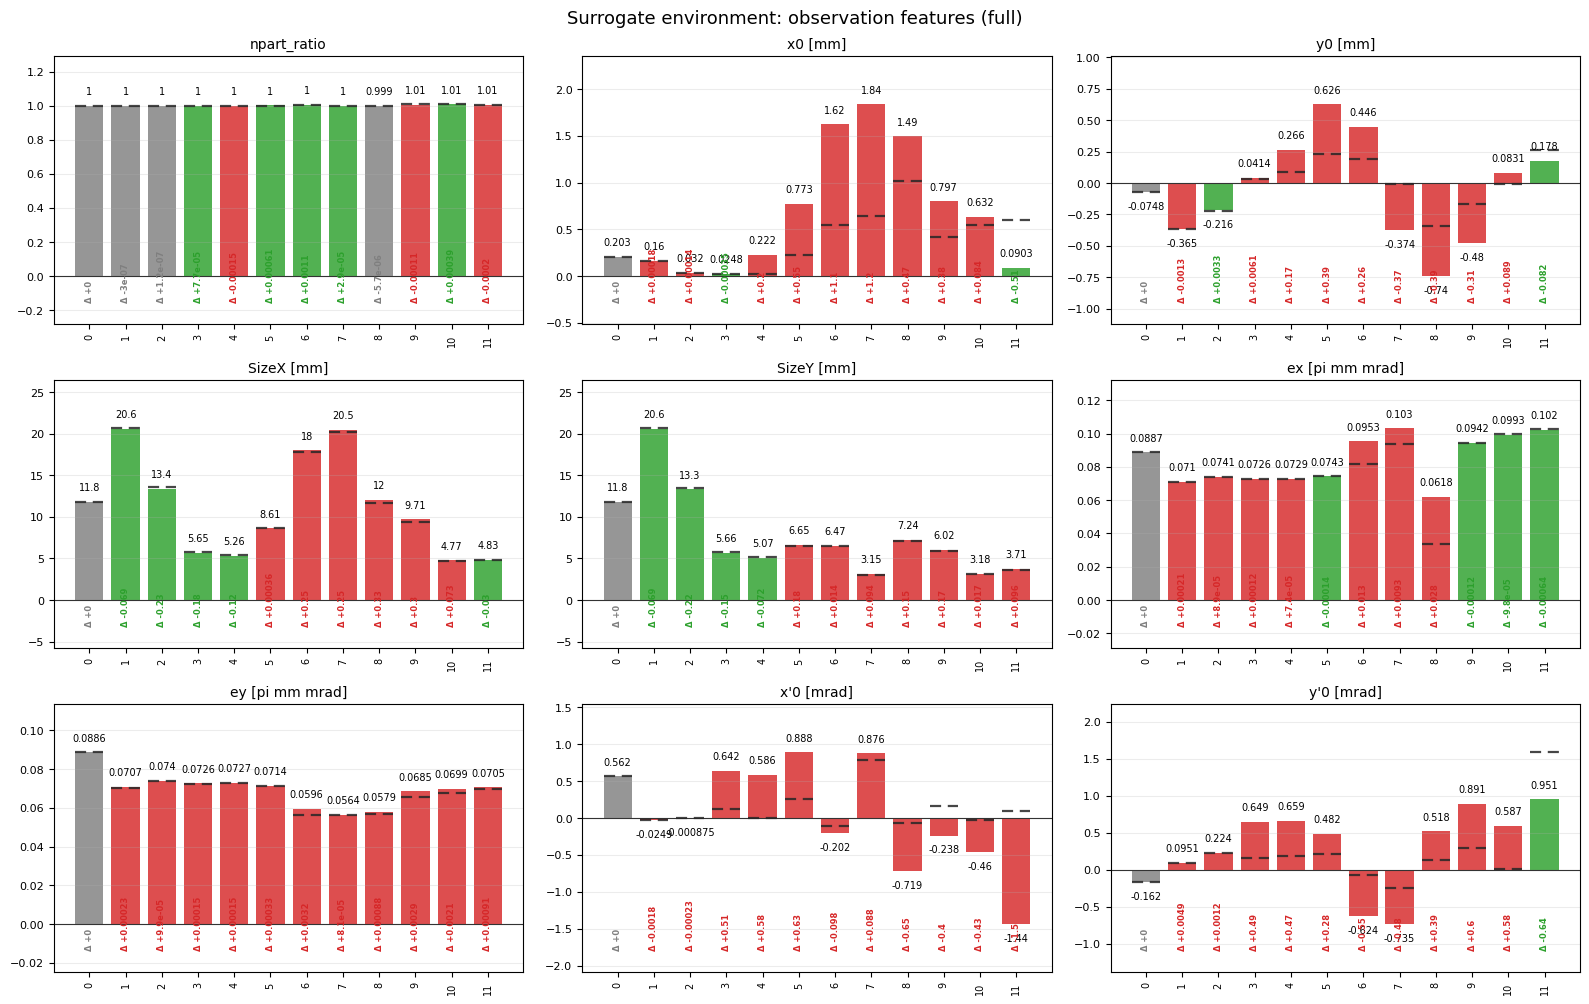

Surrogate environment: observation features (final) | obs_mode='final' | stages=['final'] | reward=-1.16347


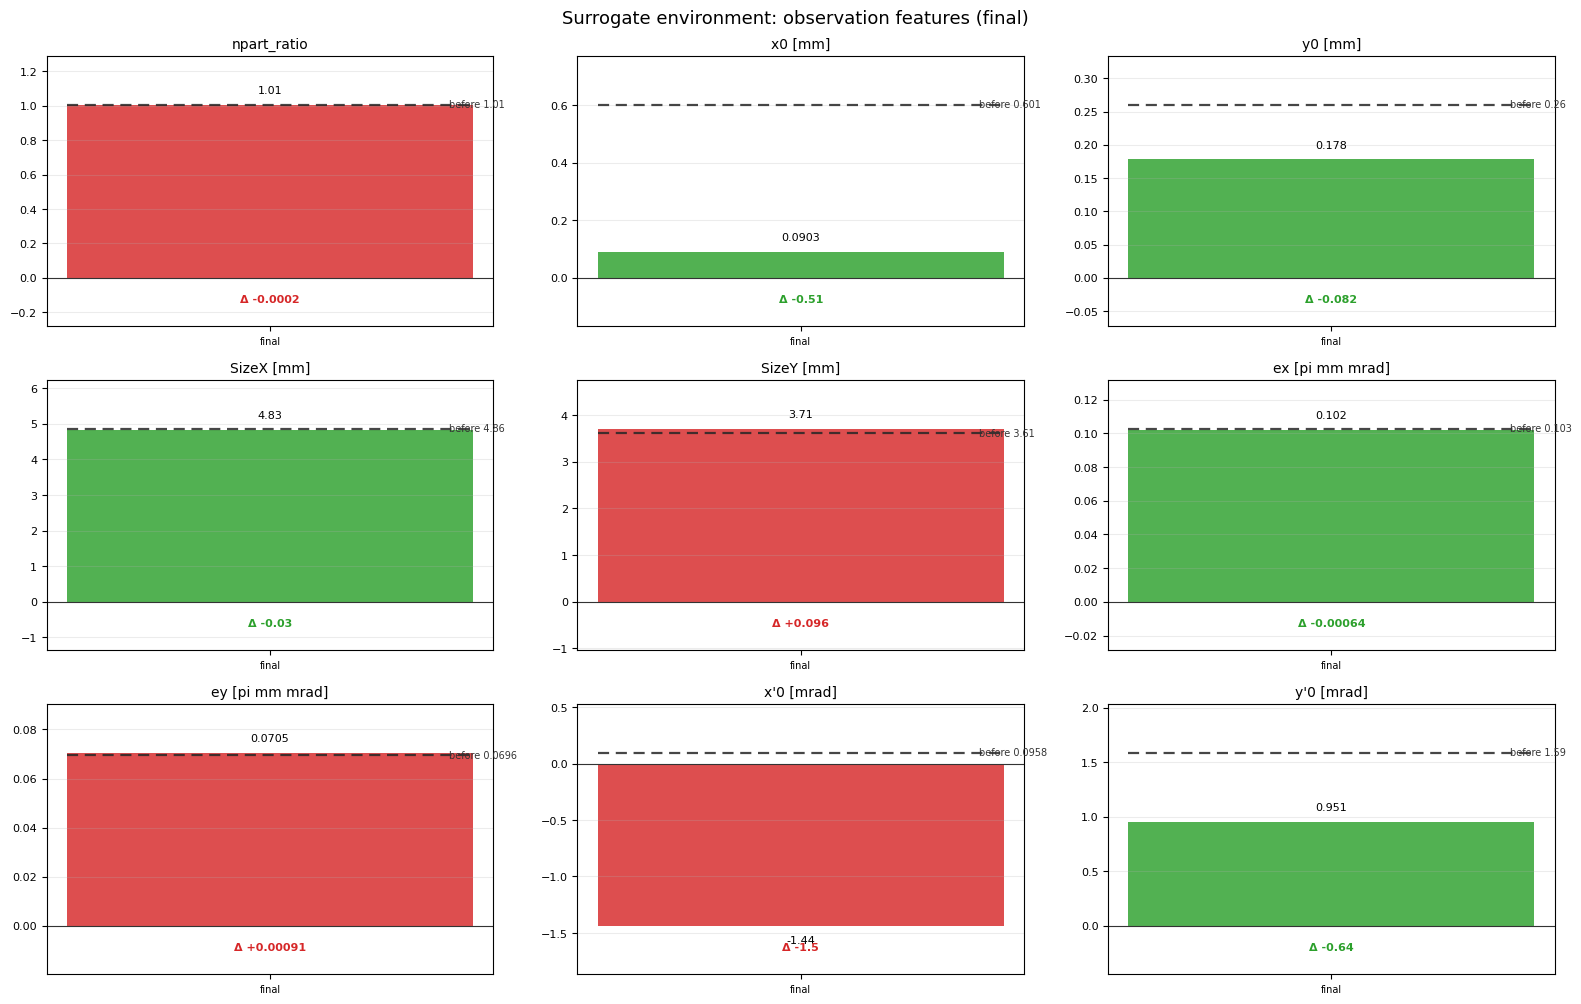

Surrogate environment: observation features (final_with_beam0) | obs_mode='final_with_beam0' | stages=['beam0', 'final'] | reward=-1.16347


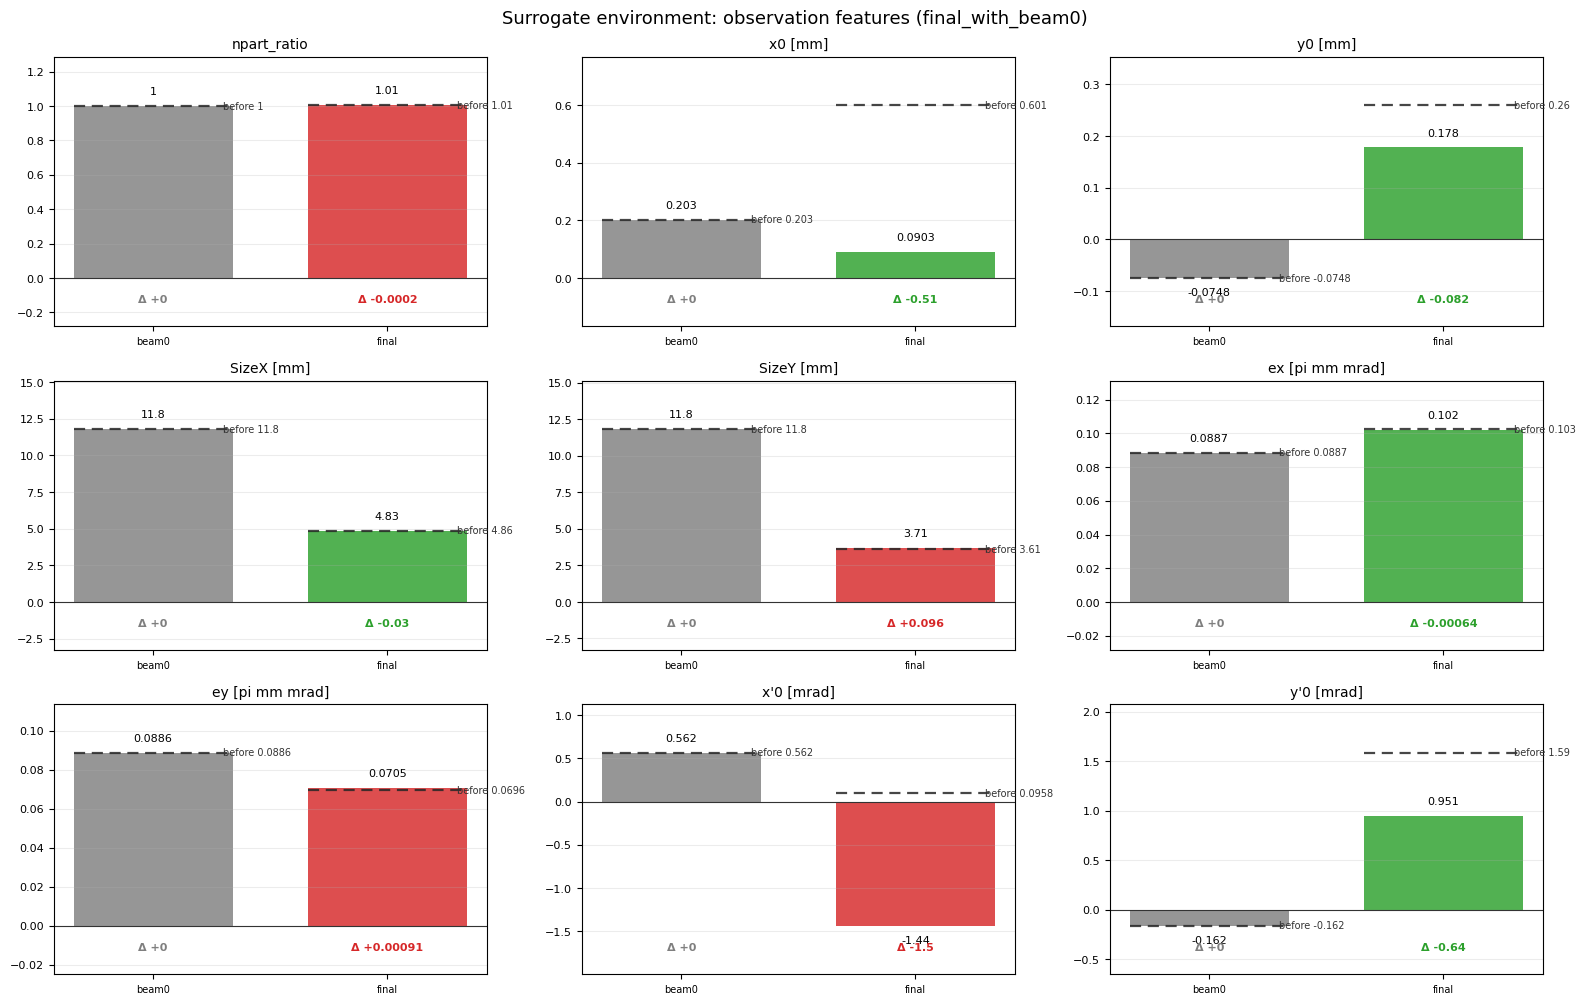

TraceWin environment
TraceWin rendering is skipped: RUN_TRACEWIN=False or tracewin_steps is not available.


In [84]:
RENDER_FEATURES = list(BEAM_STATE_VARS)


def observation_frame(obs, obs_mode):
    """Return a stage x feature table matching the agent observation mode."""
    obs = np.asarray(obs, dtype=np.float32)
    if obs_mode == "full":
        df = pd.DataFrame(obs.reshape(-1, len(BEAM_STATE_VARS)), columns=BEAM_STATE_VARS)
        df.insert(0, "stage", np.arange(len(df)))
        return df
    if obs_mode == "final":
        df = pd.DataFrame([obs], columns=BEAM_STATE_VARS)
        df.insert(0, "stage", ["final"])
        return df
    if obs_mode == "final_with_beam0":
        arr = obs.reshape(2, len(BEAM_STATE_VARS))
        df = pd.DataFrame(arr, columns=BEAM_STATE_VARS)
        df.insert(0, "stage", ["beam0", "final"])
        return df
    raise ValueError(f"Unknown obs_mode: {obs_mode}")


def feature_improved(feature, before, after):
    if feature == "npart_ratio":
        return round(float(after), 3) >= round(float(before), 3)
    if feature in {"SizeX", "SizeY", "ex", "ey"}:
        return after < before
    if feature in {"x0", "y0", "x'0", "y'0"}:
        return abs(after) < abs(before)
    return after >= before


def feature_trend(feature, before, after):
    if feature == "npart_ratio":
        return "improved" if feature_improved(feature, before, after) else "worse"
    if np.isclose(before, after):
        return "same"
    return "improved" if feature_improved(feature, before, after) else "worse"


def observed_feature_history_from_step(step_data):
    obs_mode = step_data["obs_mode"]
    before_df = observation_frame(step_data["obs_t"], obs_mode)
    after_df = observation_frame(step_data["obs_next"], obs_mode)

    rows = []
    for row_idx, stage in enumerate(after_df["stage"]):
        for feature in RENDER_FEATURES:
            before = float(before_df.loc[row_idx, feature])
            after = float(after_df.loc[row_idx, feature])
            rows.append({
                "stage": stage,
                "feature": feature,
                "unit": VAR_UNITS.get(feature, ""),
                "before": before,
                "after": after,
                "delta": after - before,
                "trend": feature_trend(feature, before, after),
            })
    return pd.DataFrame(rows)


def color_feature_delta(row):
    color = "color: green" if row["trend"] == "improved" else "color: red" if row["trend"] == "worse" else "color: black"
    return ["", "", "", "", "", color, color]


def display_feature_delta(step_data):
    table = observed_feature_history_from_step(step_data).round(6)
    try:
        display(table.style.apply(color_feature_delta, axis=1))
    except Exception:
        display(table)


def display_render_action(step_data):
    params_before = step_data.get("params_before")
    params_after = step_data.get("params_after")
    action = step_data.get("action")
    print("\nApplied action: 16-delta vector. active=True means delta != 0.")
    if params_before is None or params_after is None or action is None:
        print("Action table is not available for this step_data. Re-run the cell that creates surrogate_steps/tracewin_steps.")
        return
    display(action_table(params_before, action, params_after).round(8))


def _feature_ylim(before_values, after_values):
    values = np.asarray(list(before_values) + list(after_values), dtype=float)
    values = values[np.isfinite(values)]
    if values.size == 0:
        return -1.0, 1.0
    lo = min(0.0, float(np.nanmin(values)))
    hi = max(0.0, float(np.nanmax(values)))
    if np.isclose(lo, hi):
        pad = max(abs(hi) * 0.1, 1e-6)
        return lo - pad, hi + pad
    pad = 0.28 * (hi - lo)
    return lo - pad, hi + pad


def plot_feature_bar_panel(ax, feature_rows):
    feature_rows = feature_rows.reset_index(drop=True)
    feature = feature_rows.loc[0, "feature"]
    unit = feature_rows.loc[0, "unit"]
    stages = feature_rows["stage"].astype(str).tolist()
    before = feature_rows["before"].to_numpy(dtype=float)
    after = feature_rows["after"].to_numpy(dtype=float)
    delta = feature_rows["delta"].to_numpy(dtype=float)
    colors = [
        "tab:green" if trend == "improved" else "tab:red" if trend == "worse" else "tab:gray"
        for trend in feature_rows["trend"]
    ]

    x = np.arange(len(stages))
    width = 0.68 if len(stages) <= 3 else 0.78
    title = f"{feature}" + (f" [{unit}]" if unit else "")

    ax.bar(x, after, width=width, color=colors, alpha=0.82)
    ax.axhline(0, color="0.2", lw=0.8)
    ax.hlines(before, x - width / 2, x + width / 2, color="0.15", lw=1.6, linestyle=(0, (5, 3)), alpha=0.85)
    ax.set_ylim(*_feature_ylim(before, after))
    ax.set_xticks(x)
    ax.set_xticklabels(stages, fontsize=7, rotation=90 if len(stages) > 4 else 0)
    ax.set_title(title, fontsize=10)
    ax.grid(axis="y", alpha=0.24)
    ax.tick_params(axis="y", labelsize=8)

    y0, y1 = ax.get_ylim()
    yrange = y1 - y0
    top_pad = 0.035 * yrange
    delta_y = y0 + 0.08 * yrange

    for xi, before_i, after_i, delta_i, color_i in zip(x, before, after, delta, colors):
        va = "bottom" if after_i >= 0 else "top"
        ax.text(
            xi,
            after_i + (top_pad if after_i >= 0 else -top_pad),
            f"{after_i:.3g}",
            ha="center",
            va=va,
            fontsize=7 if len(stages) > 4 else 8,
        )
        if len(stages) <= 3:
            ax.text(
                xi + width * 0.44,
                before_i,
                f"before {before_i:.3g}",
                ha="left",
                va="center",
                fontsize=7,
                color="0.2",
            )
        ax.text(
            xi,
            delta_y,
            f"Δ {delta_i:+.2g}",
            ha="center",
            va="bottom",
            fontsize=6 if len(stages) > 4 else 8,
            color=color_i,
            fontweight="bold",
            rotation=90 if len(stages) > 4 else 0,
        )


def plot_feature_bar_dashboard(feature_table, title):
    fig, axes = plt.subplots(3, 3, figsize=(16, 10.2))
    fig.suptitle(title, fontsize=13)
    for ax, feature in zip(axes.ravel(), RENDER_FEATURES):
        rows = feature_table[feature_table["feature"] == feature]
        plot_feature_bar_panel(ax, rows)
    plt.tight_layout()
    plt.show()


def render_observation_dashboard(step_data, title):
    """Base environment rendering: feature bars only, no synthetic distribution."""
    if step_data is None:
        print(f"{title}: step_data is not available")
        return

    feature_table = observed_feature_history_from_step(step_data)
    obs_mode = step_data["obs_mode"]
    stages = observation_frame(step_data["obs_next"], obs_mode)["stage"].astype(str).tolist()

    print(f"{title} | obs_mode={obs_mode!r} | stages={stages} | reward={step_data['reward']:.6g}")
    plot_feature_bar_dashboard(feature_table, title)


def _tracewin_final_state_series(step_data, key):
    return pd.Series(np.asarray(step_data[key].beam_states, dtype=np.float32)[-1], index=BEAM_STATE_VARS)


def plot_tracewin_final_phase_spaces(step_data, title, bins=150, max_particles=40000):
    """TraceWin-only final-state diagnostic: true x-y, x-x', y-y' particle views."""
    dst_path = step_data.get("after_true_dst")
    if dst_path is None or not Path(dst_path).exists():
        print(f"{title}: final .dst file is not available")
        return

    cloud = tracewin_dst_cloud(dst_path, max_particles=max_particles, seed=1502)
    panels = [
        ("x", "y", "x [mm]", "y [mm]", "final x-y"),
        ("x", "xp", "x [mm]", "x' [mrad]", "final x-x'"),
        ("y", "yp", "y [mm]", "y' [mrad]", "final y-y'"),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.4))
    fig.suptitle(title, fontsize=13)

    for ax, (a, b, xlabel, ylabel, subtitle) in zip(axes, panels):
        a_values = cloud[a]
        b_values = cloud[b]
        arange = _limits_with_padding(a_values, 0.5, 99.5)
        brange = _limits_with_padding(b_values, 0.5, 99.5)
        h, aedge, bedge = np.histogram2d(a_values, b_values, bins=bins, range=[arange, brange])
        h_log = np.log1p(h)
        h_log[h_log == 0] = np.nan
        im = ax.pcolormesh(aedge, bedge, h_log.T, cmap="Blues", shading="auto")
        ax.axhline(0, color="black", lw=0.8, linestyle="--")
        ax.axvline(0, color="black", lw=0.8, linestyle="--")
        ax.plot(np.mean(a_values), np.mean(b_values), marker="+", color="red", markersize=13, mew=2)
        ax.set_xlim(*arange)
        ax.set_ylim(*brange)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.set_title(f"{subtitle} ({cloud['n_total']:,} particles)", fontsize=10)
        ax.tick_params(labelsize=8)
        cb = fig.colorbar(im, ax=ax, pad=0.02, fraction=0.046)
        cb.set_label("log(counts+1)", fontsize=7)
        cb.ax.tick_params(labelsize=6)

    plt.tight_layout()
    plt.show()


def render_all_observation_dashboards(step_dict, env_name):
    for obs_mode in OBS_MODES:
        if obs_mode not in step_dict:
            continue
        render_observation_dashboard(
            step_dict[obs_mode],
            f"{env_name}: observation features ({obs_mode})",
        )


def render_tracewin_dashboards_with_phase_spaces(step_dict):
    """Render TraceWin feature dashboard and true .dst phase spaces for every obs_mode."""
    for obs_mode in OBS_MODES:
        if obs_mode not in step_dict:
            print(f"TraceWin obs_mode={obs_mode!r} is not available. Re-run the TraceWin cell for all OBS_MODES.")
            continue
        step_data = step_dict[obs_mode]
        render_observation_dashboard(
            step_data,
            f"TraceWin environment: observation features ({obs_mode})",
        )
        plot_tracewin_final_phase_spaces(
            step_data,
            f"TraceWin environment: true final particle phase spaces ({obs_mode})",
        )


print("Surrogate environment")
render_all_observation_dashboards(surrogate_steps, "Surrogate environment")

print("TraceWin environment")
if RUN_TRACEWIN and tracewin_steps:
    render_tracewin_dashboards_with_phase_spaces(tracewin_steps)
else:
    print("TraceWin rendering is skipped: RUN_TRACEWIN=False or tracewin_steps is not available.")






## 6. Episodio Breve

Dopo aver visto le singole transizioni, qui facciamo un episodio breve.

Di default lo facciamo sul surrogate con `obs_mode="final"`, perche e veloce e mette al centro proprio il final state. Puoi abilitare anche TraceWin, ma ogni step TraceWin costa tempo reale.


In [ ]:
def run_short_episode(env, title, n_steps=5, seed=321):
    obs, info = env.reset(seed=seed)
    rows = []

    def add_row(step, reward, info, obs):
        result = info["sim_result"]
        if not result.success or result.beam_states is None:
            rows.append({"step": step, "obs_shape": str(obs.shape), "score": info.get("score", np.nan), "reward": reward, "error": result.error})
            return
        final = final_metrics(result.beam_states)
        rows.append({
            "step": step,
            "obs_shape": str(obs.shape),
            "score": info["score"],
            "reward": reward,
            "final_ex": final["ex"],
            "final_ey": final["ey"],
            "final_x0": final["x0"],
            "final_y0": final["y0"],
            "npart_ratio": final["npart_ratio"],
        })

    add_row(0, np.nan, info, obs)
    for i in range(1, n_steps + 1):
        sign = 1.0 if i % 2 else -1.0
        action = make_multi_param_action(env, scale=0.5 * sign)
        obs, reward, terminated, truncated, info = env.step(action)
        add_row(i, reward, info, obs)
        if terminated or truncated:
            break

    df = pd.DataFrame(rows)
    print(title)
    display(df.round(6))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(df["step"], df["score"], marker="o")
    axes[0].set_title("Score")
    axes[0].set_xlabel("step")
    axes[0].grid(alpha=0.3)

    axes[1].plot(df["step"], df["final_ex"], marker="o", label="final ex", color="tab:red")
    axes[1].plot(df["step"], df["final_ey"], marker="o", label="final ey", color="tab:blue")
    axes[1].set_title("Emittanza finale")
    axes[1].set_xlabel("step")
    axes[1].grid(alpha=0.3)
    axes[1].legend()
    plt.tight_layout()
    plt.show()
    return df


surrogate_episode = run_short_episode(
    SurrogateEnv(model=surrogates, dataset=dataset, max_steps=5, action_scale=1.0, obs_mode="final"),
    title="SurrogateEnv: episodio breve con obs_mode='final'",
    n_steps=5,
    seed=321,
)

RUN_TRACEWIN_EPISODE = False

if RUN_TRACEWIN and RUN_TRACEWIN_EPISODE:
    tracewin_episode = run_short_episode(
        TraceWinEnv(
            project_file=str(DEFAULT_TRACEWIN_INI),
            calc_dir=str(TRACEWIN_CALC_DIR),
            max_steps=3,
            action_scale=1.0,
            obs_mode="final",
            timeout=180.0,
            retries=1,
        ),
        title="TraceWinEnv: episodio breve con obs_mode='final'",
        n_steps=3,
        seed=321,
    )
else:
    print("Episodio TraceWin non eseguito. Per abilitarlo: RUN_TRACEWIN_EPISODE=True")


## Lettura Finale

Cosa guardare:

- `obs_mode="full"`: l'agente vede tutti i 12 stage, quindi shape `(108,)`;
- `obs_mode="final"`: l'agente vede solo il final state, quindi shape `(9,)`;
- `obs_mode="final_with_beam0"`: l'agente vede beam iniziale + final state, quindi shape `(18,)`.

In tutti i casi `info["sim_result"].beam_states` resta completo `(12, 9)`: serve per debug, plot e analisi. L'observation space invece e quello che cambia davvero cosa riceve l'agente.
